In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastf1 as ff1
import fastf1.plotting as ff1_plot
ff1_plot.setup_mpl(color_scheme='fastf1')
ff1.Cache.enable_cache('cache_dir')

from matplotlib import font_manager

font_manager.fontManager.addfont('Formula1-Regular.ttf')
font_manager.fontManager.addfont('Formula1-Bold.ttf')
font_manager.fontManager.addfont('Formula1-Black.ttf')
font_manager.fontManager.addfont('Formula1-Wide.ttf')
plt.rcParams['font.family'] = 'Formula1'

In [2]:
monaco_race = ff1.get_session(2026, 'Monaco', 'R')
monaco_race.load()

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['12', '44', '6', '81', '30', '41', '10', '23', '31', '14', '5', '63', '27', '43', '11', '55', '16', '18', '1', '87', '77', '3']


req            INFO 	Using cached data for driver_info


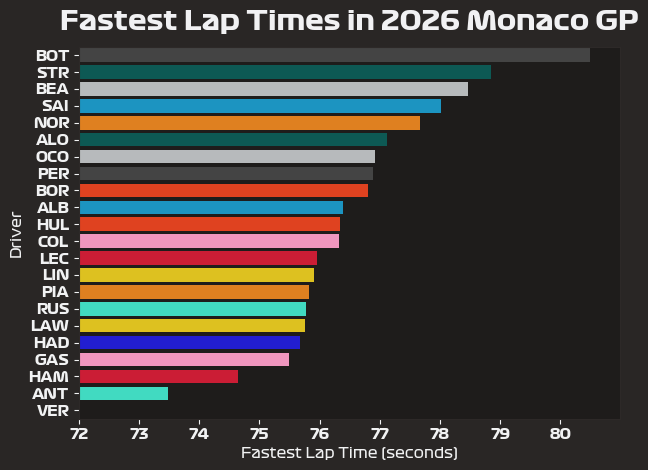

In [4]:
fastest_lap_times = monaco_race.laps.groupby('Driver')['LapTime'].min().sort_values(ascending=False).reset_index()
fastest_lap_times['LapTime'] = fastest_lap_times['LapTime'].dt.total_seconds()

colors = [ff1.plotting.get_driver_color(driver, monaco_race) for driver in fastest_lap_times['Driver']]

sns.barplot(data=fastest_lap_times, x='LapTime', y='Driver', hue='Driver', palette=colors)
plt.title('Fastest Lap Times in 2026 Monaco GP', fontweight='bold')
plt.xlabel('Fastest Lap Time (seconds)')
plt.xlim(72, fastest_lap_times['LapTime'].max()+0.5)
plt.tight_layout()
plt.show()

In [5]:
ant_laps = monaco_race.laps.pick_drivers('ANT').dropna(subset=['LapTime'])
rus_laps = monaco_race.laps.pick_drivers('RUS').dropna(subset=['LapTime'])

ant_style = ff1.plotting.get_driver_style('ANT', style=['color', 'linestyle'], session=monaco_race)
rus_style = ff1.plotting.get_driver_style('RUS', style=['color', 'linestyle'], session=monaco_race)

ant_color = ant_style['color']
rus_color = 'white'

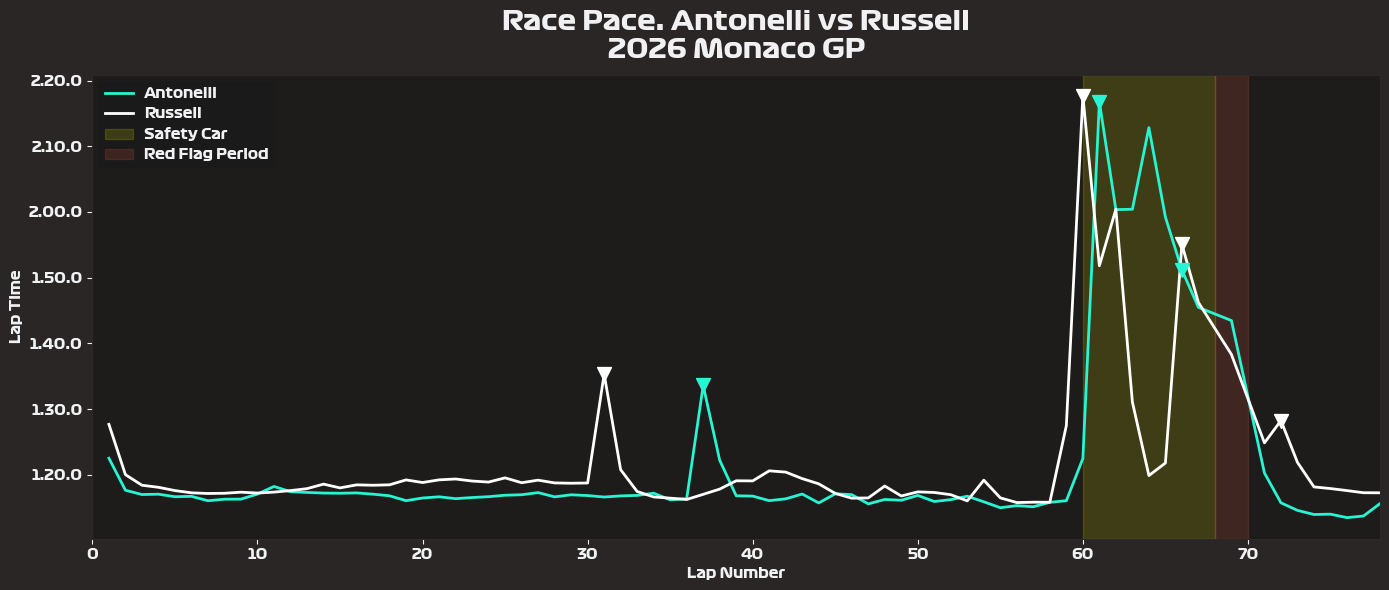

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ant_laps['LapNumber'], ant_laps['LapTime'], **ant_style, linewidth=2, label='Antonelli')
ax.plot(rus_laps['LapNumber'], rus_laps['LapTime'], color=rus_color, linewidth=2, label='Russell')

ax.axvspan(60, 68, alpha=0.15, color='yellow', label='Safety Car')
ax.axvspan(68, 70, alpha=0.15, color='tomato', label='Red Flag Period')

ant_pit_times = ant_laps[ant_laps['PitInTime'].notna()]
rus_pit_times = rus_laps[rus_laps['PitInTime'].notna()]

ax.scatter(ant_pit_times['LapNumber'], ant_pit_times['LapTime'], color=ant_color, marker='v', s=100, zorder=5, label='_nolegend_')
ax.scatter(rus_pit_times['LapNumber'], rus_pit_times['LapTime'], color=rus_color, marker='v', s=100, zorder=5, label='_nolegend_')

ax.set_xlabel('Lap Number', fontweight='bold')
ax.set_ylabel('Lap Time', fontweight='bold')
ax.set_title('Race Pace: Antonelli vs Russell\n2026 Monaco GP', fontweight='bold')
ax.legend()

plt.xlim(0, 78)
plt.tight_layout()
plt.show()

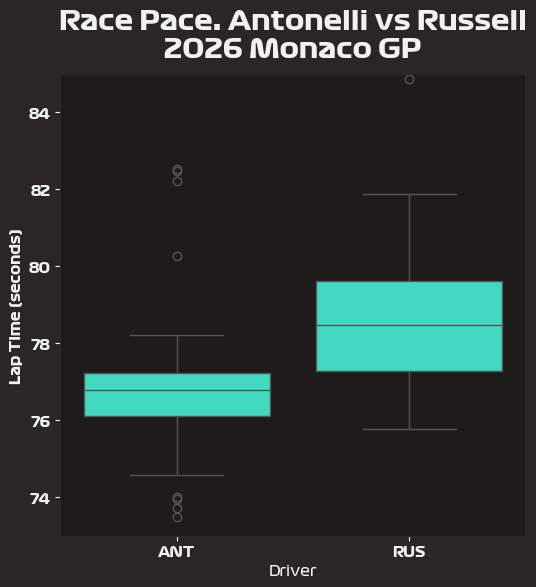

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ant_rus_laps = monaco_race.laps.pick_drivers(['ANT', 'RUS']).copy()
ant_rus_laps['LapTimeSeconds'] = ant_rus_laps['LapTime'].dt.total_seconds()
sns.boxplot(data=ant_rus_laps, y='LapTimeSeconds', x='Driver', hue='Driver', palette=[ant_style['color'], rus_style['color']])
plt.ylim(73, 85)
plt.title('Race Pace: Antonelli vs Russell\n2026 Monaco GP', fontweight='bold')
plt.ylabel('Lap Time (seconds)', fontweight='bold')
plt.show()

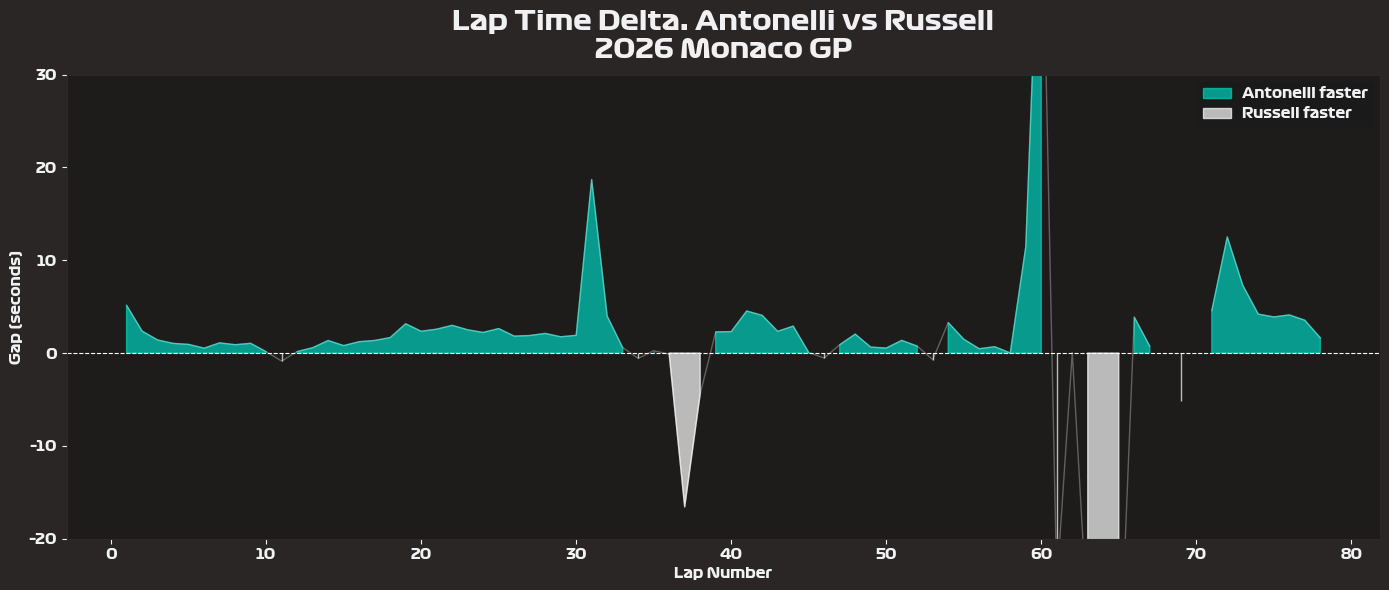

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ant_rus_laps_pivoted = ant_rus_laps[['LapNumber', 'Driver', 'LapTimeSeconds']].pivot(index='LapNumber', columns='Driver', values='LapTimeSeconds').reset_index().rename_axis(None, axis=1)
ant_rus_gap = ant_rus_laps_pivoted['RUS'] - ant_rus_laps_pivoted['ANT']
laps = ant_rus_laps_pivoted['LapNumber']

ax.plot(laps, ant_rus_gap, color='white', linewidth=1, alpha=0.3)
ax.fill_between(laps, ant_rus_gap, 0, where=(ant_rus_gap > 0), color='#00D2BE', alpha=0.7, label='Antonelli faster')
ax.fill_between(laps, ant_rus_gap, 0, where=(ant_rus_gap < 0), color='white', alpha=0.7, label='Russell faster')
ax.axhline(y=0, color='white', linewidth=0.8, linestyle='--')
    
ax.set_xlabel('Lap Number', fontweight='bold')
ax.set_ylabel('Gap (seconds)', fontweight='bold')
ax.set_title('Lap Time Delta: Antonelli vs Russell\n2026 Monaco GP', fontweight='bold')
ax.legend()

plt.ylim(-20, 30)
plt.tight_layout()
plt.show()

In [9]:
def format_laptime(td):
    total_seconds = td.total_seconds()
    minutes = int(total_seconds // 60)
    seconds = total_seconds % 60
    return f"{minutes:02.0f}:{seconds:06.3f}"

In [23]:
fastest_ant = ant_laps.pick_fastest()
fastest_rus = rus_laps.pick_fastest()
telemetry_ant = fastest_ant.get_car_data().add_distance()
telemetry_rus = fastest_rus.get_car_data().add_distance()
telemetry_ant['Driver'] = 'ANT'
telemetry_rus['Driver'] = 'RUS'
delta_time, ref_tel, compare_tel = ff1.utils.delta_time(fastest_ant, fastest_rus)

/Users/billtaing/formula1/venv/lib/python3.12/site-packages/fastf1/utils.py:85: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because it hasa tendency to give inaccurate results.
  warnings.warn("`utils.delta_time` is considered deprecated and will"


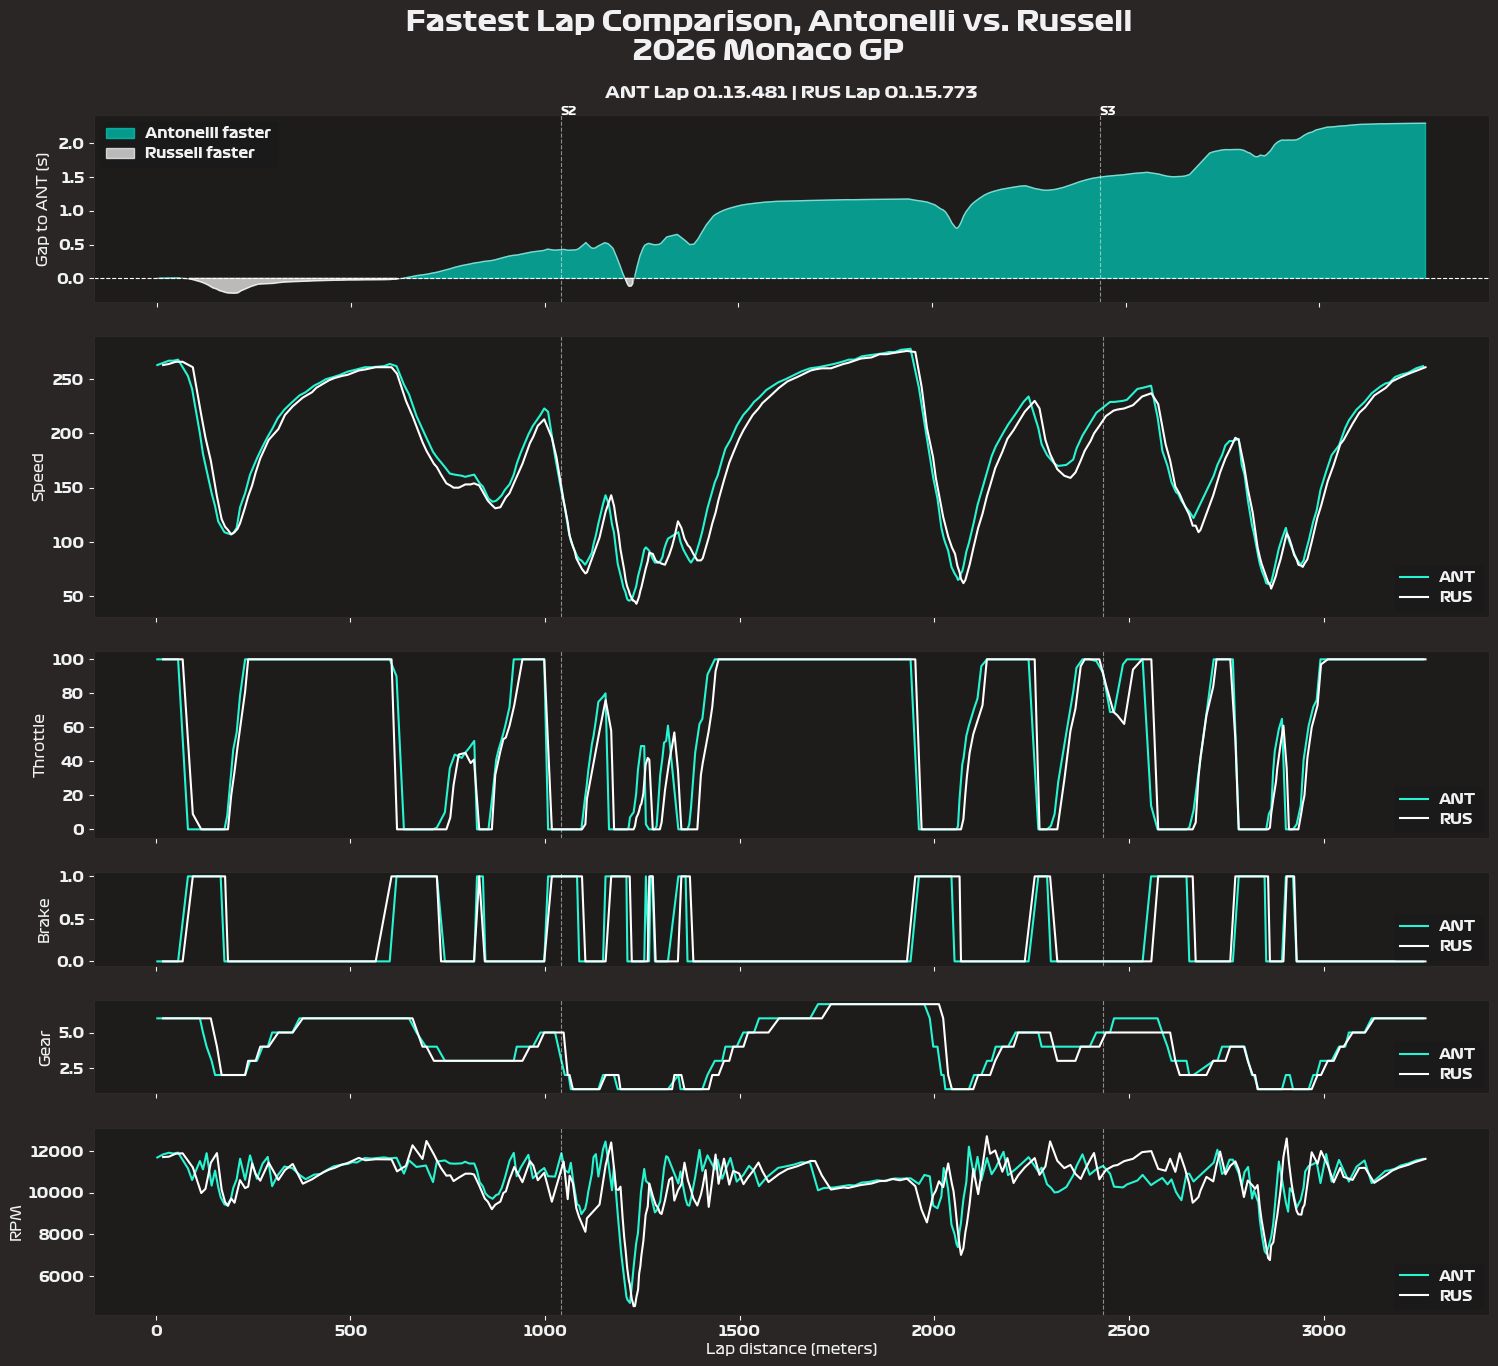

In [24]:
plt.rcParams['figure.figsize'] = [18, 15]
fig, ax = plt.subplots(6, gridspec_kw={'height_ratios': [2, 3, 2, 1, 1, 2]})
fig.suptitle("Fastest Lap Comparison, Antonelli vs. Russell\n2026 Monaco GP", size=20, fontweight='bold')
ax[0].set_title(f"ANT Lap {format_laptime(fastest_ant['LapTime'])} | RUS Lap {format_laptime(fastest_rus['LapTime'])}", size=12, fontweight='bold')
plt.subplots_adjust(top=0.91)

ax[0].plot(ref_tel['Distance'], delta_time, color='white', linewidth=1, alpha=0.5)
ax[0].fill_between(ref_tel['Distance'], delta_time, 0, where=(delta_time > 0), color='#00D2BE', alpha=0.7, label='Antonelli faster')
ax[0].fill_between(ref_tel['Distance'], delta_time, 0, where=(delta_time < 0), color='white', alpha=0.7, label='Russell faster')
ax[0].axhline(0, color='white', linestyle='--', linewidth=0.8)
ax[0].set(ylabel=f"Gap to ANT (s)")
ax[0].legend()

ax[1].plot(telemetry_ant['Distance'], telemetry_ant['Speed'], label='ANT', color=ant_color)
ax[1].plot(telemetry_rus['Distance'], telemetry_rus['Speed'], label='RUS', color=rus_color)
ax[1].set(ylabel='Speed')
ax[1].legend(loc="lower right")

ax[2].plot(telemetry_ant['Distance'], telemetry_ant['Throttle'], label='ANT', color=ant_color)
ax[2].plot(telemetry_rus['Distance'], telemetry_rus['Throttle'], label='RUS', color=rus_color)
ax[2].set(ylabel='Throttle')
ax[2].legend(loc="lower right")

ax[3].plot(telemetry_ant['Distance'], telemetry_ant['Brake'], label='ANT', color=ant_color)
ax[3].plot(telemetry_rus['Distance'], telemetry_rus['Brake'], label='RUS', color=rus_color)
ax[3].set(ylabel='Brake')
ax[3].legend(loc="lower right")

ax[4].plot(telemetry_ant['Distance'], telemetry_ant['nGear'], label='ANT', color=ant_color)
ax[4].plot(telemetry_rus['Distance'], telemetry_rus['nGear'], label='RUS', color=rus_color)
ax[4].set(ylabel='Gear')
ax[4].legend(loc="lower right")

ax[5].plot(telemetry_ant['Distance'], telemetry_ant['RPM'], label='ANT', color=ant_color)
ax[5].plot(telemetry_rus['Distance'], telemetry_rus['RPM'], label='RUS', color=rus_color)
ax[5].set(ylabel='RPM')
ax[5].set(xlabel='Lap distance (meters)')
ax[5].legend(loc="lower right")

for a in ax.flat:
    a.label_outer()

sector1_dist = telemetry_ant[telemetry_ant['SessionTime'] >= fastest_ant['Sector1SessionTime']].iloc[0]['Distance']
sector2_dist = telemetry_ant[telemetry_ant['SessionTime'] >= fastest_ant['Sector2SessionTime']].iloc[0]['Distance']

for a in ax:
    a.axvline(x=sector1_dist, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
    a.axvline(x=sector2_dist, color='white', linewidth=0.8, linestyle='--', alpha=0.5)

# Label them on the top subplot only
ax[0].text(sector1_dist, ax[0].get_ylim()[1], 'S2', color='white', fontsize=8)
ax[0].text(sector2_dist, ax[0].get_ylim()[1], 'S3', color='white', fontsize=8)

plt.show()